In [3]:
import pandas as pd

In [4]:
tabela_usinas = pd.read_parquet("tabela_usinas.parquet")

### Calcula índices de flexibilidade para cada tecnologia
- O cálculo é feito para cada tecnologia, por subsistema do SIN, considerando 1, 2, 4 e 6 horas de rampa.
- O cálculo considera as fontes solar e eólica de forma negativa (demanda de flexibilidade)
- Enquanto considera outras fontes são consideradas de forma positiva (oferta de flexibilidade).

In [13]:
sistemas = tabela_usinas['id_subsistema'].unique()
filtro_REN = tabela_usinas['nom_tipousina'].isin(['EOLIELÉTRICA', 'FOTOVOLTAICA'])
df_flex = pd.DataFrame()

for sistema in sistemas:
    filtro_sistema = tabela_usinas['id_subsistema'] == sistema
    for horas in [1, 2, 4, 6]:
        tecnologias = tabela_usinas.loc[filtro_sistema, 'nom_tipousina'].unique()
        for tecnologia in tecnologias:
            filtro_tecnologia = filtro_sistema & (tabela_usinas['nom_tipousina'] == tecnologia)
            tipos_combustivel = tabela_usinas.loc[filtro_tecnologia, 'nom_tipocombustivel'].unique()
            for combustivel in tipos_combustivel:
                filtro_combustivel = filtro_tecnologia & (tabela_usinas['nom_tipocombustivel'] == combustivel)
                cap_instalada = tabela_usinas.loc[filtro_combustivel, 'P max'].sum()
                if cap_instalada == 0:
                    continue
                if tecnologia in ['EOLIELÉTRICA', 'FOTOVOLTAICA']:
                    flex_indice = (-1 * tabela_usinas.loc[filtro_combustivel, "Ind Flex Down Horario P" + str(horas)] * tabela_usinas.loc[filtro_combustivel, 'P max']).sum()/cap_instalada
                else:
                    flex_indice = (tabela_usinas.loc[filtro_combustivel, "Ind Flex Down Horario P" + str(horas)] * tabela_usinas.loc[filtro_combustivel, 'P max']).sum()/cap_instalada
                
                # Armazena os resultados em uma lista de dicionários                
                if 'resultados_flex' not in locals():
                    resultados_flex = []
                resultados_flex.append({
                    'sistema': sistema,
                    'combustivel': combustivel,
                    'tecnologia': tecnologia,
                    'horas': horas,
                    'flex_indice': flex_indice
                })
df_flex = pd.DataFrame(resultados_flex)

In [6]:
# tabela_usinas.to_parquet("tabela_usinas.parquet", index=False)

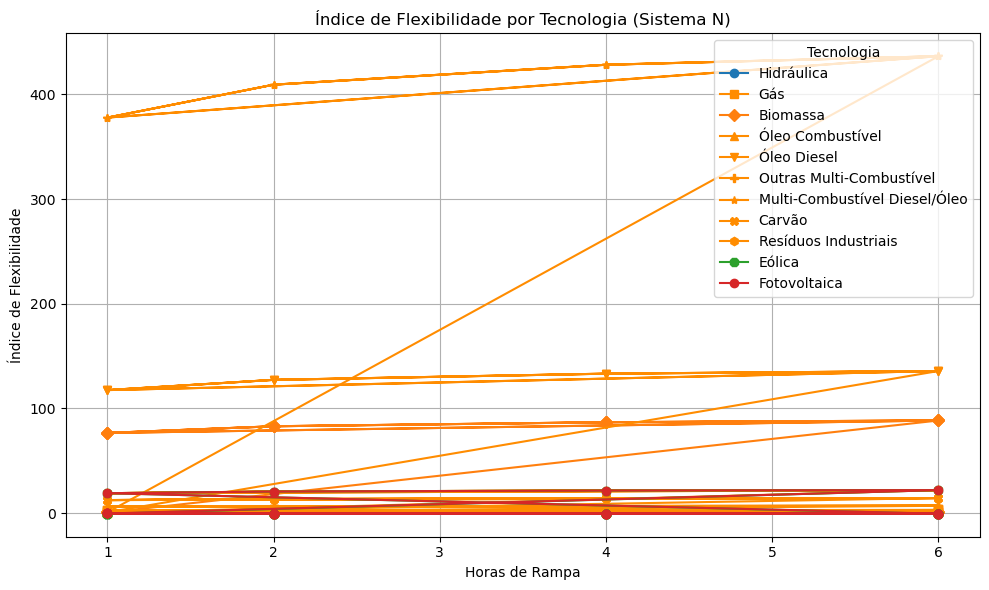

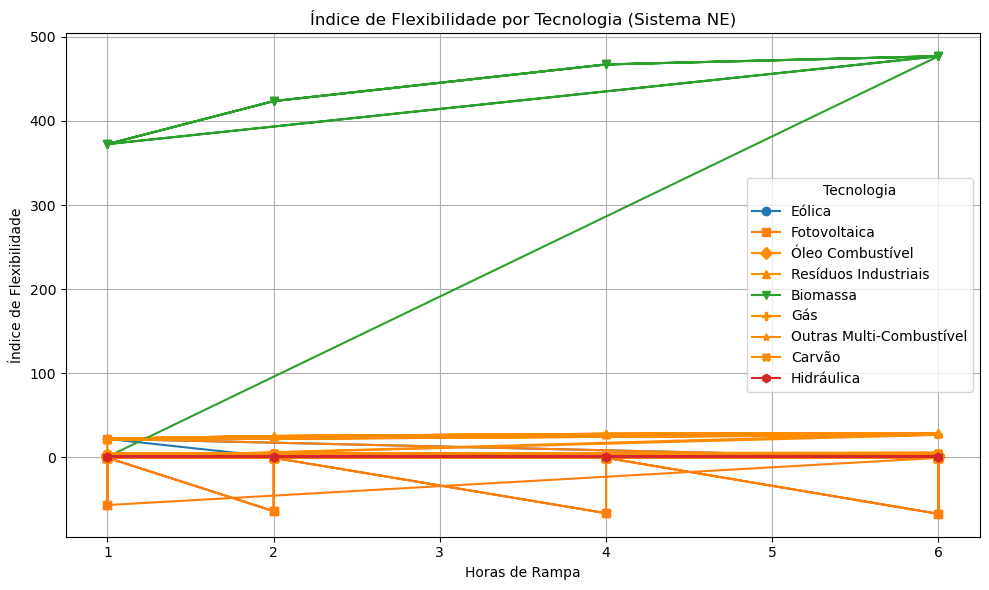

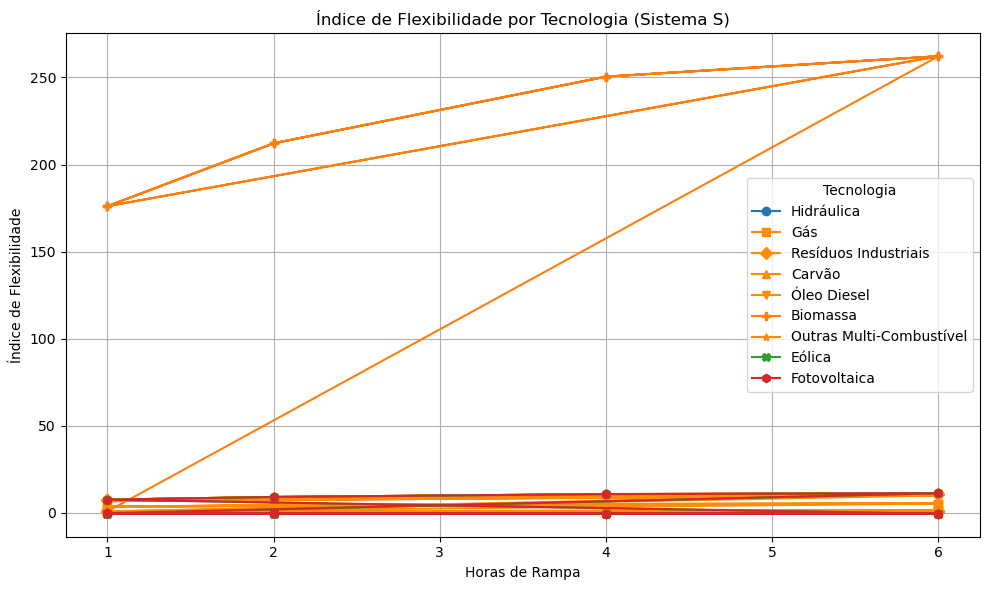

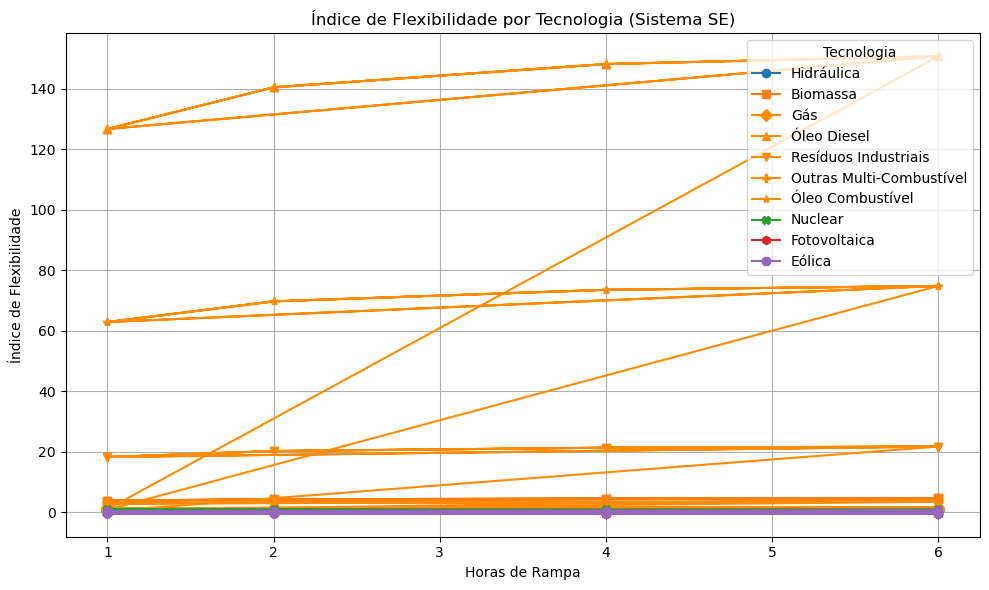

In [14]:
import pandas as pd

import matplotlib.pyplot as plt
df_flex = pd.DataFrame(resultados_flex)
sistemas = df_flex['sistema'].unique()
for sistema in sistemas:
    # Filtra apenas para o sistema 'SE'
    df_se = df_flex[df_flex['sistema'] == sistema]
    combustiveis_se = df_flex[df_flex['sistema'] == sistema]['combustivel'].unique()

    plt.figure(figsize=(10, 6))
    cor_termica = '#FF8C00'  # laranja para TÉRMICA

    for idx, combustivel in enumerate(combustiveis_se):
        dados_combustivel = df_se[df_se['combustivel'] == combustivel]
        # Se a tecnologia for TÉRMICA, usa cor laranja, senão usa cor padrão do loop
        tecnologia = dados_combustivel['tecnologia'].iloc[0] if not dados_combustivel.empty else None
        if tecnologia == 'TÉRMICA' and combustivel not in ['Nuclear', "Biomassa"]:
            cor = cor_termica
        else:
            cor = None  # usa cor padrão do matplotlib
        marcadores = ['o', 's', 'D', '^', 'v', 'P', '*', 'X', 'h', '8']
        marcador = marcadores[idx % len(marcadores)]
        plt.plot(
            dados_combustivel['horas'],
            dados_combustivel['flex_indice'],
            marker=marcador,
            label=combustivel,
            color=cor
        )

    plt.xlabel('Horas de Rampa')
    plt.ylabel('Índice de Flexibilidade')
    plt.title('Índice de Flexibilidade por Tecnologia (Sistema ' + str(sistema) + ')')
    plt.legend(title='Tecnologia')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
